# Dax Virani | Titanic Data Cleaning and Feature Engineering
A notebook-first cleaning pipeline with validation, safer imputations, feature engineering, and survival-aware profiling.

In [1]:
import pandas as pd
import numpy as np
import io
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.facecolor": "#F8FAFC",
    "axes.facecolor": "#FFFFFF",
    "font.family": "DejaVu Sans",
    "axes.titleweight": "bold"
})

RAW_CSV = """PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.25,,S
2,1,1,"Cumings, Mrs. John Bradley",female,38,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.925,,S
4,1,1,"Futrelle, Mrs. Jacques Heath",female,35,1,0,113803,53.1,C123,S
5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.05,,S
6,0,3,"Moran, Mr. James",male,,0,0,330877,8.4583,,Q
7,0,1,"McCarthy, Mr. Timothy J",male,54,0,0,17463,51.8625,E46,S
8,0,3,"Palsson, Master. Gosta Leonard",male,2,3,1,349909,21.075,,S
9,1,3,"Johnson, Mrs. Oscar W",female,27,0,2,347742,11.1333,,S
10,1,2,"Nasser, Mrs. Nicholas",female,14,1,0,237736,30.0708,,C
11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4,1,1,PP 9549,16.7,G6,S
12,1,1,"Bonnell, Miss. Elizabeth",female,58,0,0,113783,26.55,C103,S
13,0,3,"Saundercock, Mr. William Henry",male,20,0,0,A/5. 2151,8.05,,S
14,0,3,"Andersson, Mr. Anders Johan",male,39,1,5,347082,31.275,,S
15,0,3,"Vestrom, Miss. Hulda Amanda Adolfina",female,14,0,0,350406,7.8542,,S
15,0,3,"Vestrom, Miss. Hulda Amanda Adolfina",female,14,0,0,350406,7.8542,,S
16,1,2,"Hewlett, Mrs. Mary D",female,55,0,0,248706,16,,S
17,0,3,"Rice, Master. Eugene",male,2,4,1,382652,29.125,,Q
18,1,2,"Williams, Mr. Charles Eugene",male,,0,0,244373,13,,
19,0,3,"Vander Planke, Mrs. Julius",female,31,1,0,345763,18,,S
20,1,3,"Masselmani, Mrs. Fatima",female,,0,0,2649,7.225,,C
"""

df = pd.read_csv(io.StringIO(RAW_CSV))
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Data Audit
This stage quantifies missingness, duplicates, and field types before any transformation happens.

In [2]:
display(pd.DataFrame({"rows": [len(df)], "columns": [df.shape[1]], "missing": [int(df.isna().sum().sum())], "duplicates": [int(df.duplicated().sum())]}))
display(df.dtypes.to_frame("dtype"))
display(df.isna().sum()[df.isna().sum() > 0].to_frame("missing_count"))

,rows,columns,missing,duplicates
0,21,12,20,1


,dtype
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


,missing_count
Age,3
Cabin,16
Embarked,1


## Cleaning and Feature Engineering
The notebook uses median imputation for numeric fields, mode for categoricals, then engineers family and title signals.

In [3]:
df = df.drop_duplicates().copy()
for column in df.select_dtypes(include=[np.number]).columns:
    if df[column].isna().any():
        df[column] = df[column].fillna(df[column].median())
for column in df.select_dtypes(include="object").columns:
    if df[column].isna().any():
        df[column] = df[column].fillna(df[column].mode()[0])

df["survived"] = df["Survived"].astype(int)
df["ticket_class"] = df["Pclass"].astype(int)
df["sex"] = df["Sex"]
df["family_size"] = df["SibSp"] + df["Parch"] + 1
df["is_alone"] = (df["family_size"] == 1).astype(int)
df["title"] = df["Name"].str.split(", " ).str[-1].str.split(".").str[0]
df["deck"] = df["Cabin"].astype(str).str[0].replace({"n": np.nan})
df["fare_band"] = pd.qcut(df["Fare"], q=4, labels=["low", "mid", "high", "premium"])
df["age_band"] = pd.cut(df["Age"], bins=[0, 12, 18, 35, 60, 120], labels=["child", "teen", "young_adult", "adult", "senior"], include_lowest=True)

display(df[["survived", "ticket_class", "family_size", "is_alone", "title", "fare_band", "age_band"]].head())
display(df.describe(include="all").transpose().head(12))

,survived,ticket_class,family_size,is_alone,title,fare_band,age_band
0,0,3,2,0,Mr,low,young_adult
1,1,1,2,0,Mrs,premium,adult
2,1,3,1,1,Miss,low,young_adult
3,1,1,2,0,Mrs,premium,young_adult
4,0,3,1,1,Mr,low,young_adult


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,20.0,NaN,NaN,NaN,10.5,5.91608,1.0,5.75,10.5,15.25,20.0
Survived,20.0,NaN,NaN,NaN,0.5,0.512989,0.0,0.0,0.5,1.0,1.0
Pclass,20.0,NaN,NaN,NaN,2.45,0.825578,1.0,2.0,3.0,3.0,3.0
Name,20,20,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,20,2,female,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,20.0,NaN,NaN,NaN,27.85,16.320072,2.0,18.5,27.0,35.75,58.0
SibSp,20.0,NaN,NaN,NaN,0.7,1.080935,0.0,0.0,0.0,1.0,4.0
Parch,20.0,NaN,NaN,NaN,0.5,1.192079,0.0,0.0,0.0,0.25,5.0
Ticket,20,20,A/5 21171,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,20.0,NaN,NaN,NaN,22.19937,18.058888,7.225,8.05,16.35,29.36145,71.2833


## Validation and Survival Profiling
A compact validation report is paired with survival-aware comparisons to keep the cleaning work grounded in the target variable.

,remaining_nulls,invalid_age,invalid_fare,duplicate_ids
0,0,0,0,0


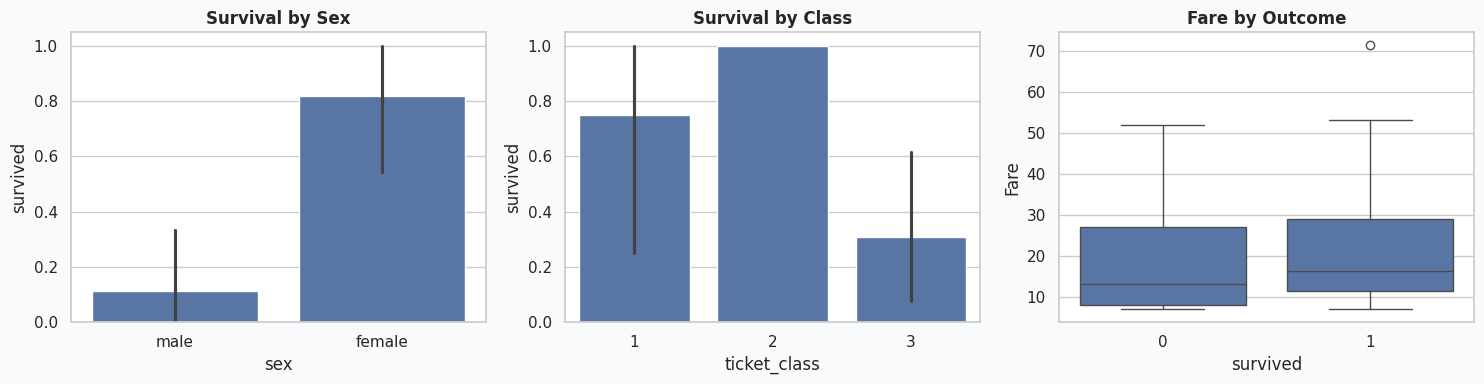

In [4]:
issues = {
    "remaining_nulls": int(df.isna().sum().sum()),
    "invalid_age": int(((df["Age"] < 0) | (df["Age"] > 120)).sum()),
    "invalid_fare": int((df["Fare"] < 0).sum()),
    "duplicate_ids": int(df["PassengerId"].duplicated().sum())
}
display(pd.DataFrame([issues]))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.barplot(data=df, x="sex", y="survived", ax=axes[0])
axes[0].set_title("Survival by Sex")
sns.barplot(data=df, x="ticket_class", y="survived", ax=axes[1])
axes[1].set_title("Survival by Class")
sns.boxplot(data=df, x="survived", y="Fare", ax=axes[2])
axes[2].set_title("Fare by Outcome")
plt.tight_layout()
plt.show()

## Cleaned Output Snapshot
The final dataframe is tidy, typed, and enriched with features that support modeling or deeper exploratory analysis.

In [5]:
final_columns = ["PassengerId", "survived", "ticket_class", "Name", "sex", "Age", "SibSp", "Parch", "Ticket", "Fare", "Cabin", "Embarked", "family_size", "is_alone", "title", "fare_band", "age_band"]
display(df[final_columns].head())

,PassengerId,survived,ticket_class,Name,sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,family_size,is_alone,title,fare_band,age_band
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,C103,S,2,0,Mr,low,young_adult
1,2,1,1,"Cumings, Mrs. John Bradley",female,38.0,1,0,PC 17599,71.2833,C85,C,2,0,Mrs,premium,adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,C103,S,1,1,Miss,low,young_adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath",female,35.0,1,0,113803,53.1000,C123,S,2,0,Mrs,premium,young_adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,C103,S,1,1,Mr,low,young_adult
